# Notebook para Exploração de Dados e Engenharia de Features

## Exploração de Dados e Engenharia de Features - Volatilidade de Criptomoedas

**Objetivo:** Carregar os dados OHLCV coletados do banco de dados PostgreSQL, explorar suas características e iniciar a engenharia de features para o modelo de detecção/previsão de volatilidade.

### 1. Configuração e Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine 
import os
import sys

In [2]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (15, 7)
pd.set_option('display.max_columns', None)

### 2. Carregar Configurações e Conectar ao Banco de Dados

In [3]:
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    print(f"Adicionando {project_root} ao sys.path")
    sys.path.insert(0, project_root)

try:
    from src.config import DATABASE_URL
except ImportError as e:
    print(f"Erro ao importar DATABASE_URL de src.config: {e}")
    print("Certifique-se de que está executando este notebook a partir do diretório 'notebooks/'")
    print("e que o arquivo src/config.py existe e está correto.")

try:
    engine = create_engine(DATABASE_URL)
    with engine.connect() as connection:
        print("Conexão com o banco de dados bem-sucedida!")
except Exception as e:
    print(f"Falha ao conectar ou criar engine: {e}")
    engine = None

Adicionando d:\Projetos\crypto-volatility-detector ao sys.path
Conexão com o banco de dados bem-sucedida!


### 3. Carregar Dados do Banco

In [4]:
target_symbol = "BTCUSDT"
target_interval = "1d"

query = f"""
SELECT * FROM klines_ohlcv 
WHERE symbol = '{target_symbol}' 
  AND interval_time = '{target_interval}'
ORDER BY open_time ASC;
"""

if engine:
    try:
        print(f"Carregando dados para {target_symbol} ({target_interval})...")
        df_raw = pd.read_sql(query, engine, index_col='open_time', parse_dates=['open_time', 'close_time'])
        print(f"Dados carregados com sucesso! {len(df_raw)} registros encontrados.")

        df = df_raw.copy()
    except Exception as e:
        print(f"Erro ao carregar dados do banco: {e}")
        df = pd.DataFrame()
else:
    print("Engine do banco de dados não está configurado. Não é possível carregar dados.")
    df = pd.DataFrame()

Carregando dados para BTCUSDT (1d)...
Dados carregados com sucesso! 1000 registros encontrados.


### 4. Exploração Inicial dos Dados (EDA)

In [5]:
print("Primeiras 5 linhas:")
display(df.head())
print("\nÚltimas 5 linhas:")
display(df.tail())

Primeiras 5 linhas:


,id,symbol,interval_time,open_price,high_price,low_price,close_price,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume
open_time,,,,,,,,,,,,,
2022-08-17 00:00:00+00:00,5,BTCUSDT,1d,23856.15,24446.71,23180.40,23342.66,210668.68766,2022-08-17 23:59:59.999000+00:00,4.993659e+09,6901586,105158.87989,2.493209e+09
2022-08-18 00:00:00+00:00,6,BTCUSDT,1d,23342.66,23600.00,23111.04,23191.20,144185.97011,2022-08-18 23:59:59.999000+00:00,3.375339e+09,6029662,71864.05086,1.682459e+09
2022-08-19 00:00:00+00:00,7,BTCUSDT,1d,23191.45,23208.67,20783.57,20834.39,283995.87747,2022-08-19 23:59:59.999000+00:00,6.181759e+09,8860928,139601.81043,3.038568e+09
2022-08-20 00:00:00+00:00,8,BTCUSDT,1d,20834.39,21382.85,20761.90,21140.07,183041.68363,2022-08-20 23:59:59.999000+00:00,3.871243e+09,5723362,91862.59461,1.943014e+09
2022-08-21 00:00:00+00:00,9,BTCUSDT,1d,21140.07,21800.00,21069.11,21515.61,159200.68410,2022-08-21 23:59:59.999000+00:00,3.405035e+09,5034461,80239.24190,1.716251e+09



Últimas 5 linhas:


,id,symbol,interval_time,open_price,high_price,low_price,close_price,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume
open_time,,,,,,,,,,,,,
2025-05-08 00:00:00+00:00,1000,BTCUSDT,1d,97030.50,104145.76,96876.29,103261.60,34962.02847,2025-05-08 23:59:59.999000+00:00,3.508646e+09,4991147,18547.23009,1.861334e+09
2025-05-09 00:00:00+00:00,1001,BTCUSDT,1d,103261.61,104361.30,102315.14,102971.99,27617.39907,2025-05-09 23:59:59.999000+00:00,2.847518e+09,4406929,14525.20381,1.497827e+09
2025-05-10 00:00:00+00:00,1002,BTCUSDT,1d,102971.99,104984.57,102818.76,104809.53,15324.78611,2025-05-10 23:59:59.999000+00:00,1.588386e+09,2227845,8258.23478,8.560953e+08
2025-05-11 00:00:00+00:00,1003,BTCUSDT,1d,104809.53,104972.00,103345.06,104118.00,17987.12197,2025-05-11 23:59:59.999000+00:00,1.873382e+09,3100176,9071.95578,9.449033e+08
2025-05-12 00:00:00+00:00,1004,BTCUSDT,1d,104118.00,105819.45,102544.25,102800.02,21240.47003,2025-05-12 23:59:59.999000+00:00,2.216570e+09,3294422,11333.14979,1.183429e+09


In [6]:
print("\nInformações do DataFrame:")
df.info()


Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1000 entries, 2022-08-17 00:00:00+00:00 to 2025-05-12 00:00:00+00:00
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype              
---  ------                        --------------  -----              
 0   id                            1000 non-null   int64              
 1   symbol                        1000 non-null   object             
 2   interval_time                 1000 non-null   object             
 3   open_price                    1000 non-null   float64            
 4   high_price                    1000 non-null   float64            
 5   low_price                     1000 non-null   float64            
 6   close_price                   1000 non-null   float64            
 7   volume                        1000 non-null   float64            
 8   close_time                    1000 non-null   datetime64[ns, UTC]
 9   quote_asset_volume            10

In [7]:
print("\nEstatísticas Descritivas:")
numeric_cols_df = df.select_dtypes(include=np.number)
display(numeric_cols_df.describe())


Estatísticas Descritivas:


,id,open_price,high_price,low_price,close_price,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1.000000e+03,1000.000000,1.000000e+03
mean,504.500000,49356.968520,50336.443210,48396.645520,49435.916030,88412.874701,2.764513e+09,3.257464e+06,43898.771463,1.369312e+09
std,288.819436,26918.828217,27484.692469,26337.694476,26959.688625,116853.016444,2.403305e+09,2.759743e+06,58403.497572,1.205612e+09
min,5.000000,15781.290000,16315.000000,15476.000000,15781.290000,5420.221140,2.508740e+08,3.108520e+05,2284.191780,1.165812e+08
25%,254.750000,26343.752500,26781.747500,25982.202500,26365.992500,23637.709383,1.159758e+09,1.181151e+06,11612.020787,5.593718e+08
50%,504.500000,42571.880000,43356.505000,41692.025000,42581.440000,36698.941500,1.943106e+09,2.149480e+06,18100.754560,9.599958e+08
75%,754.250000,67825.600000,68940.760000,66522.492500,67842.885000,81232.975688,3.519031e+09,4.799626e+06,40391.949490,1.777754e+09
max,1004.000000,106143.820000,109588.000000,105321.490000,106143.820000,760705.362783,1.746531e+10,1.522359e+07,374775.574085,8.783916e+09


In [8]:
print("\nValores Ausentes por Coluna:")
display(df.isnull().sum())


Valores Ausentes por Coluna:


id                              0
symbol                          0
interval_time                   0
open_price                      0
high_price                      0
low_price                       0
close_price                     0
volume                          0
close_time                      0
quote_asset_volume              0
number_of_trades                0
taker_buy_base_asset_volume     0
taker_buy_quote_asset_volume    0
dtype: int64

#### Visualização Inicial

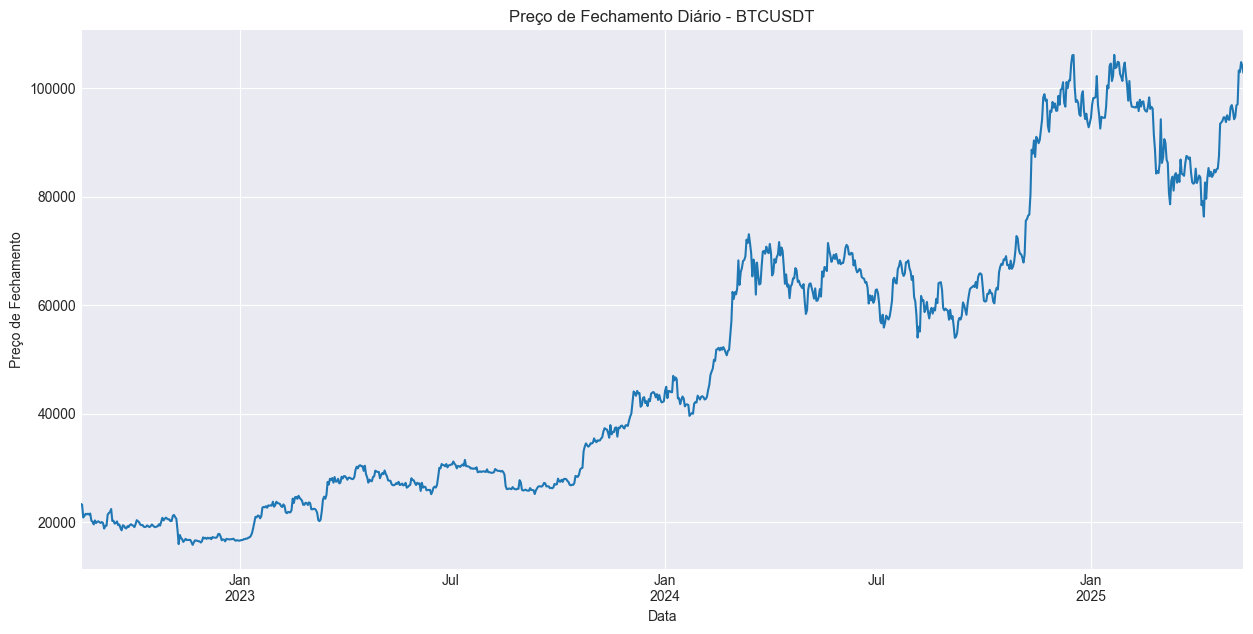

In [9]:
# Plotar o preço de fechamento ao longo do tempo
if not df.empty and 'close_price' in df.columns:
    plt.figure(figsize=(15, 7))
    df['close_price'].plot(title=f'Preço de Fechamento Diário - {target_symbol}')
    plt.ylabel("Preço de Fechamento")
    plt.xlabel("Data")
    plt.show()
else:
    print("DataFrame vazio ou sem coluna 'close_price' para plotar.")

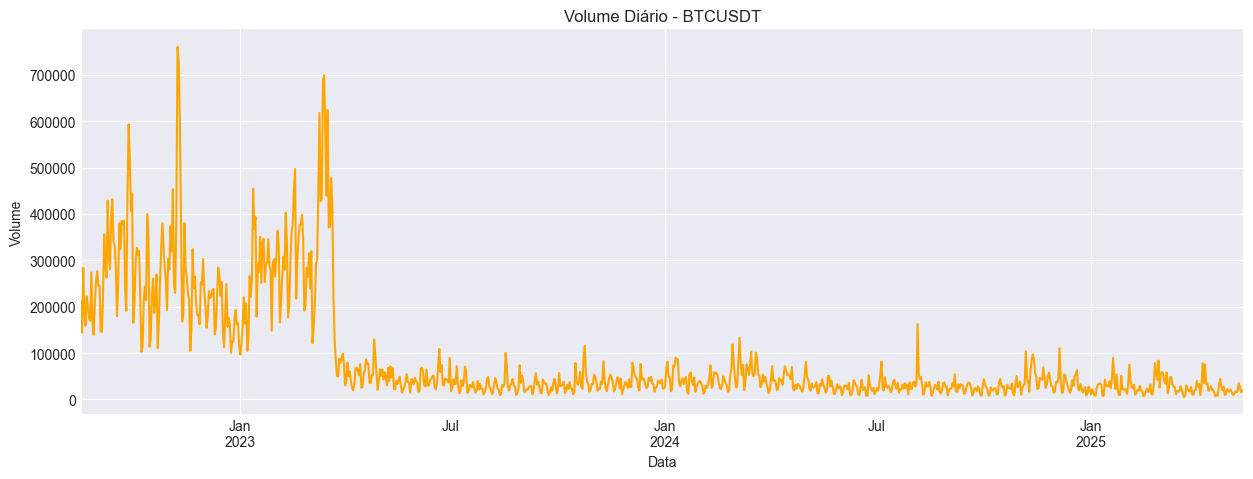

In [10]:
# Plotar o volume negociado ao longo do tempo
if not df.empty and 'volume' in df.columns:
    plt.figure(figsize=(15, 5))
    df['volume'].plot(title=f'Volume Diário - {target_symbol}', color='orange')
    plt.ylabel("Volume")
    plt.xlabel("Data")
    plt.show()
else:
    print("DataFrame vazio ou sem coluna 'volume' para plotar.")


### 5. Engenharia de Features - Volatilidade


Retornos diários calculados:


,close_price,daily_return
open_time,,
2022-08-18 00:00:00+00:00,23191.20,-0.006489
2022-08-19 00:00:00+00:00,20834.39,-0.101625
2022-08-20 00:00:00+00:00,21140.07,0.014672
2022-08-21 00:00:00+00:00,21515.61,0.017764
2022-08-22 00:00:00+00:00,21399.83,-0.005381


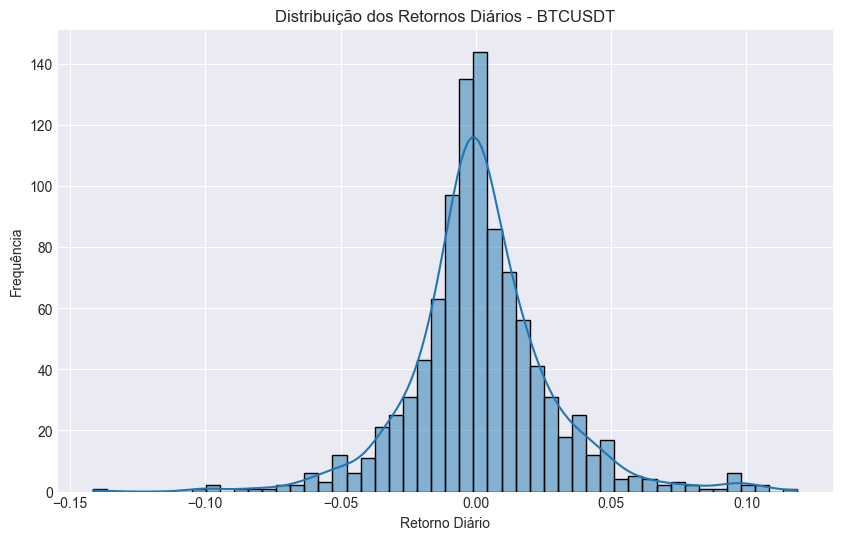

In [11]:
# Calcular Retornos Diários (Variação Percentual do Preço de Fechamento)
if not df.empty and 'close_price' in df.columns:
    df['daily_return'] = df['close_price'].pct_change()
    df = df.dropna(subset=['daily_return']) 
    print("\nRetornos diários calculados:")
    display(df[['close_price', 'daily_return']].head())
    
    # Plotar a distribuição dos retornos diários
    plt.figure(figsize=(10, 6))
    sns.histplot(df['daily_return'].dropna(), bins=50, kde=True)
    plt.title(f'Distribuição dos Retornos Diários - {target_symbol}')
    plt.xlabel('Retorno Diário')
    plt.ylabel('Frequência')
    plt.show()
else:
    print("Não foi possível calcular retornos diários.")


Volatilidade histórica (janela de 21 dias) calculada:


,daily_return,historical_volatility
open_time,,
2025-05-08 00:00:00+00:00,0.064218,0.417479
2025-05-09 00:00:00+00:00,-0.002805,0.415806
2025-05-10 00:00:00+00:00,0.017845,0.416999
2025-05-11 00:00:00+00:00,-0.006598,0.421317
2025-05-12 00:00:00+00:00,-0.012659,0.423892


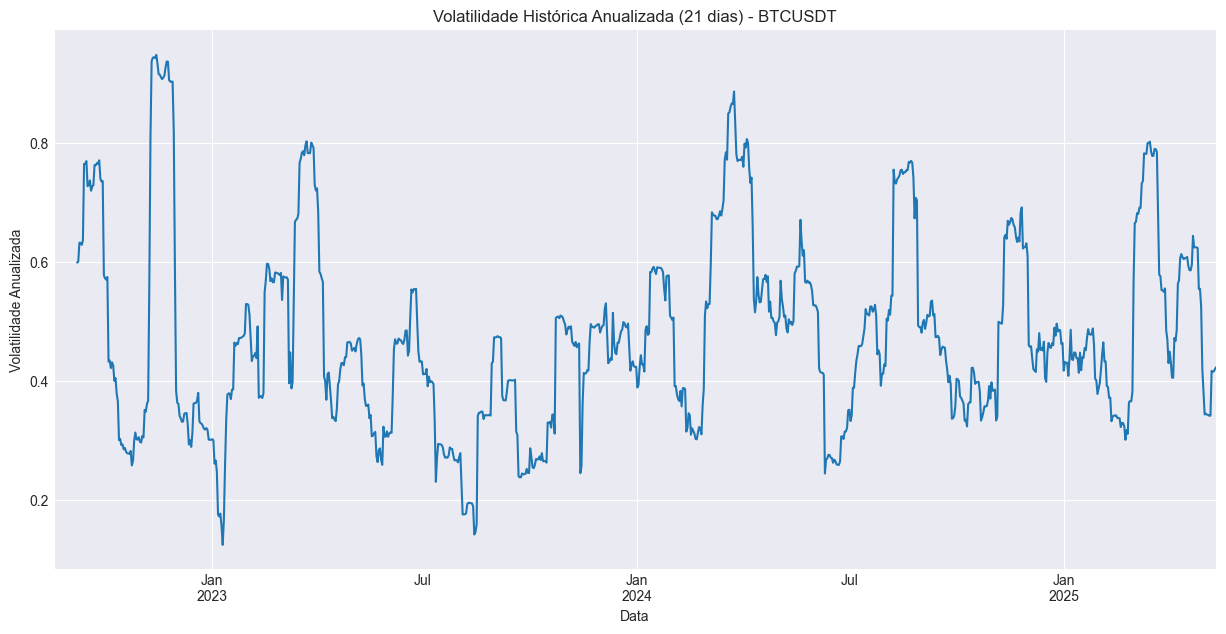

In [12]:
# Calcular Volatilidade Histórica (Desvio Padrão Móvel dos Retornos)
# Usaremos uma janela móvel de, por exemplo, 21 dias (aproximadamente 1 mês de negociação)
if 'daily_return' in df.columns:
    window_size = 21 
    df['historical_volatility'] = df['daily_return'].rolling(window=window_size).std() * np.sqrt(365)
    
    print(f"\nVolatilidade histórica (janela de {window_size} dias) calculada:")
    display(df[['daily_return', 'historical_volatility']].tail()) # Mostra o final onde há valores calculados

    plt.figure(figsize=(15, 7))
    df['historical_volatility'].plot(title=f'Volatilidade Histórica Anualizada ({window_size} dias) - {target_symbol}')
    plt.ylabel("Volatilidade Anualizada")
    plt.xlabel("Data")
    plt.show()
else:
    print("Coluna 'daily_return' não encontrada para calcular volatilidade histórica.")

In [13]:
output_dir_processed = '../data/processed' # Caminho relativo para a pasta data/processed
os.makedirs(output_dir_processed, exist_ok=True)
filename_processed = f"{output_dir_processed}/{target_symbol}_{target_interval}_features.csv"

try:
    # Salvar apenas se o DataFrame não estiver vazio
    if not df.empty:
        df.to_csv(filename_processed)
        print(f"\nDataFrame com features iniciais salvo em: {filename_processed}")
    else:
        print("\nDataFrame vazio, nenhum arquivo salvo.")
except Exception as e:
    print(f"Erro ao salvar DataFrame processado: {e}")


DataFrame com features iniciais salvo em: ../data/processed/BTCUSDT_1d_features.csv
